<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("mjohn326_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,falkonml_falkon,00447cc08941a87f8e7f9988434cd38934327e68,gmeanti <giacomo.meanti@gmail.com>,1618143109,Update keops v1.5\n,2021-04
1,falkonml_falkon,00ba481b0aaeae97f1bd2eb91ca6c358cc06d9c7,gmeanti <giacomo.meanti@gmail.com>,1643726346,Add example notebooks\n,2022-02
2,falkonml_falkon,010647df36805f9c934529b5ba4eba3106bd4566,gmeanti <giacomo.meanti@gmail.com>,1618578389,Add docs to batch-mmv\n,2021-04
3,falkonml_falkon,01115b0e48e276d686212dafc5ac1a57a3ebff41,gmeanti <giacomo.meanti@gmail.com>,1618346125,Add square norm compiled\n,2021-04
4,falkonml_falkon,018393b4fc887dad2e46528fa34302eaff627b33,gmeanti <giacomo.meanti@gmail.com>,1631001800,trace\n,2021-09


In [3]:
# projects = ['falkonml_falkon', 'juliamanifolds_manopt.jl', 'neuroml_pyneuroml', 'henriqueslab_zerocostdl4mic',\
#            'frankyeh_dsi-studio', 'andreatramacere_jetset', 'micycle1_tinfour', 'vinecopulib_pyvinecopulib',\
#            'elfi-dev_elfi', 'mattjj_pyhsmm']

prj = 'mattjj_pyhsmm'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')

#Save info
timeseries = monthly_counts[['Month', 'Commits']].copy()
timeseries = timeseries.rename(columns={'Commits': '#Commits'})
timeseries.to_csv(f'commits_timeseries/mjohn326_commits_timeseries_{prj}.csv', sep=';', index=False)

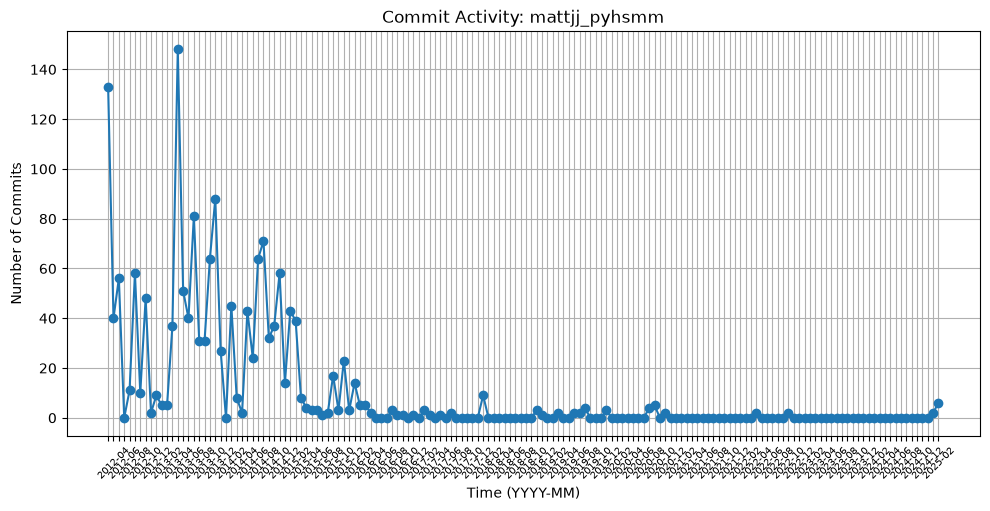

In [4]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("commits_png/mjohn326_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

In [5]:
from urllib.request import Request, urlopen
import json

patterns = {}
 
urls = pd.read_csv('net2prj.csv').set_index('WoC')['GH'].to_dict()
rows = []
 
for project, pdf in df.groupby('project'):
    #Monthly timeline with empty months filled as 0
    months = pd.to_datetime(pdf['time'], unit='s').dt.to_period('M')
    counts = months.value_counts().sort_index()
    timeline = counts.reindex(pd.period_range(counts.index.min(), counts.index.max(), freq='M'), fill_value=0)
 
    gaps, start, length = [], None, 0
    for month, n in timeline.items():
        if n == 0:
            start = start or month
            length += 1
        elif start:
            gaps.append((start, month - 1, length))
            start, length = None, 0
 
    longest = max(gaps, key=lambda g: g[2]) if gaps else (None, None, 0)
 
    #GitHub stars, forks, last commit date
    stars = forks = last = None
    owner, repo = str(urls.get(project, '')).rstrip('/').removesuffix('.git').split('/')[-2:]
    api = f'https://api.github.com/repos/{owner}/{repo}'
    info = json.load(urlopen(Request(api), timeout=10))
    commit = json.load(urlopen(Request(api + '/commits?per_page=1'), timeout=10))[0]
    stars, forks, last = info['stargazers_count'], info['forks_count'], commit['commit']['committer']['date'][:10]

    rows.append({
        'project': project,
        '#commits': len(pdf),
        '#authors': pdf['author'].nunique(),
        'From': pdf['time'].min(),
        'To': pdf['time'].max(),
        '#stars': stars,
        '#forks': forks,
        'LastGHCommitDate': last,
        'LongestGapStart (YYYY-MM)': longest[0].strftime('%Y-%m') if longest[0] else '',
        'LongestGapEnd (YYYY-MM)': longest[1].strftime('%Y-%m') if longest[1] else '',
        'LongestGapLength (months)': longest[2],
        'NumCommitsAfterLastGap': int((months > longest[1]).sum()) if longest[1] else 0,
        'NumberOfGapsInTimeline': sum(g[2] >= 3 for g in gaps),
        'ActivityPattern': patterns.get(project, ''),
    })
 
stats = pd.DataFrame(rows)
stats.to_csv('mjohn326_project_stats.csv', sep=';', index=False)
stats

,project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,andreatramacere_jetset,1802,11,1513267133,1777126784,43,15,2024-09-11,2018-05,2018-10,6,1771,2,
1,elfi-dev_elfi,3439,50,1475485419,1746708077,283,62,2026-10-08,2019-06,2019-10,5,1132,4,
2,falkonml_falkon,1085,17,1592412606,1752740728,201,26,2026-05-13,2024-08,2025-06,11,14,1,
3,frankyeh_dsi-studio,9249,18,1345574784,1775852352,167,72,2026-10-09,,,0,0,0,
4,henriqueslab_zerocostdl4mic,1750,63,1581499133,1762347305,654,144,2026-10-06,2025-05,2025-05,1,31,0,
5,juliamanifolds_manopt.jl,6046,73,1480068070,1762334369,427,52,2026-10-04,2017-08,2018-05,10,5979,3,
6,mattjj_pyhsmm,1610,33,1332089141,1739056097,579,178,2025-01-25,2022-11,2024-12,26,8,8,
7,micycle1_tinfour,746,7,1465156185,1760902709,0,0,2026-06-25,2021-10,2022-04,7,107,8,
8,neuroml_pyneuroml,2868,42,1418234813,1758770947,53,35,2026-07-21,2016-10,2016-11,2,2509,0,
9,vinecopulib_pyvinecopulib,1116,16,1490689253,1760006141,128,23,2026-10-08,2018-06,2019-06,13,995,5,


# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

# Interpretation

1) Irregular pattern with huge spikes every so often. The gaps that are there sit low in the chart about 3-4 months at a time.
2) Sharp decline at the beginning but remained steady. I believe the longest gap was 5 months.
3) Started as a sharp decline then became more of a steady decline. There's a big steady gap towards the end for about 13 months.
4) Steady at first then became irregular. Most gaps lasted between 1-2 months.
5) Very active project with an irregular pattern. Very few gaps that lasted no more than a month.
6) Had the longest gap for 10 months at the beginning and became active afterwards. It has somewhat of a cyclical pattern. You could tell when activity would come, but not how high it would be.
7) High activity at the beginning but fell off drastically in the middle. Steady gaps that lasted 8-10 months.
8) Irregular pattern. There is a noticable decline, but still unpredictable. Gaps typically last between 3 to 5 months.
9) Still irregular with 1-3 month gaps.
10) Overall, not much activity with a sharp spike in the middle. Big gaps at the start where one last almost 2 years.


# Part 3.1

In [6]:
#Used AI to help come up with common words to sort the out the themes for each project.

import re
from collections import Counter

themes = [
    ('Automated bot contributions', r'\[bot\]|dependabot|renovate|github-actions|pre-commit-ci|\bbot\b'),
    ('Security patches',            r'secur|vulnerab|\bcve\b|xss|csrf|injection'),
    ('Dependency updates',          r'\bbump|depend|upgrade|requirements|package(-lock)?\.json|\bdeps?\b'),
    ('Release',                     r'releas|\bversion\b|changelog|\bv?\d+\.\d+(\.\d+)?\b|\btag'),
    ('Documentation updates',       r'\bdoc|readme|typo|comment|tutorial|example'),
    ('Bug fixes',                   r'\bfix|\bbug|error|issue|crash|patch|resolve|correct'),
    ('Feature development',         r'\badd|feature|implement|support|\bnew\b|introduce|create|enable'),
]

def theme_of(row):
    text = f"{row['author']} {row['message']}".lower()
    return next((name for name, pattern in themes if re.search(pattern, text)), 'Other')

def top2(rows):
    return ':'.join(t for t, _ in Counter(rows.apply(theme_of, axis=1)).most_common(2)) if len(rows) else ''

stats['BeforeThemes'] = ''
stats['AfterThemes'] = ''

if 'month' not in df.columns:
    df['month'] = pd.to_datetime(df['time'], unit='s').dt.to_period('M')

gap_rows = []

for i, s in stats.iterrows():
    gap_start = s.get('LongestGapStart (YYYY-MM)')
    gap_end = s.get('LongestGapEnd (YYYY-MM)')
    
    #Check if project has no gap
    if pd.isna(gap_start) or not str(gap_start).strip():
        continue

    commits = df[df['project'] == s['project']].sort_values('time')
    
    pre = commits[commits['month'] < pd.Period(gap_start, 'M')].tail(10).copy()
    post = commits[commits['month'] > pd.Period(gap_end, 'M')].head(10).copy()

    #Grab the top 2 themes
    stats.loc[i, 'BeforeThemes'] = top2(pre)
    stats.loc[i, 'AfterThemes'] = top2(post)

    #If not empty, add to list
    if not pre.empty:
        pre['pre/post'] = 'pre'
        gap_rows.append(pre)
        
    if not post.empty:
        post['pre/post'] = 'post'
        gap_rows.append(post)

#Concatenate and save gap commits

gap_commits = pd.concat(gap_rows, ignore_index=True)

desired_cols = ['pre/post', 'project', 'author', 'commit', 'time', 'message']

#Selecting existing columns 
existing_cols = [c for c in desired_cols if c in gap_commits.columns]
gap_commits = gap_commits[existing_cols]

gap_commits.to_csv('mjohn326_project_gap_commits.csv', sep=';', index=False)

stats.to_csv('mjohn326_project_stats.csv', sep=';', index=False)
stats

,project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern,BeforeThemes,AfterThemes
0,andreatramacere_jetset,1802,11,1513267133,1777126784,43,15,2024-09-11,2018-05,2018-10,6,1771,2,,Bug fixes:Feature development,Other:Bug fixes
1,elfi-dev_elfi,3439,50,1475485419,1746708077,283,62,2026-10-08,2019-06,2019-10,5,1132,4,,Other:Release,Other:Release
2,falkonml_falkon,1085,17,1592412606,1752740728,201,26,2026-05-13,2024-08,2025-06,11,14,1,,Other:Bug fixes,Other:Bug fixes
3,frankyeh_dsi-studio,9249,18,1345574784,1775852352,167,72,2026-10-09,,,0,0,0,,,
4,henriqueslab_zerocostdl4mic,1750,63,1581499133,1762347305,654,144,2026-10-06,2025-05,2025-05,1,31,0,,Other:Feature development,Other:Bug fixes
5,juliamanifolds_manopt.jl,6046,73,1480068070,1762334369,427,52,2026-10-04,2017-08,2018-05,10,5979,3,,Feature development:Bug fixes,Documentation updates:Bug fixes
6,mattjj_pyhsmm,1610,33,1332089141,1739056097,579,178,2025-01-25,2022-11,2024-12,26,8,8,,Other:Dependency updates,Other:Documentation updates
7,micycle1_tinfour,746,7,1465156185,1760902709,0,0,2026-06-25,2021-10,2022-04,7,107,8,,Other:Release,Bug fixes:Release
8,neuroml_pyneuroml,2868,42,1418234813,1758770947,53,35,2026-07-21,2016-10,2016-11,2,2509,0,,Other:Release,Feature development:Other
9,vinecopulib_pyvinecopulib,1116,16,1490689253,1760006141,128,23,2026-10-08,2018-06,2019-06,13,995,5,,Other:Bug fixes,Other:Documentation updates


# Part 3.2

In [13]:
#AI helped with loading the links and grabbing the proper names

import os

stats = pd.read_csv('mjohn326_project_stats.csv', sep=';')
for c in ['Currentstatus', 'RecentThemes', 'HypothesizedGapReason', 'HasRecovered',
          'WhyRecovered', 'WhoRecovered', 'Notes']:
    stats[c] = ''
urls = pd.read_csv('net2prj.csv').set_index('WoC')['GH'].to_dict()
df['month'] = pd.to_datetime(df['time'], unit='s').dt.to_period('M')
os.makedirs('reflection', exist_ok=True)
 
for i, s in stats.iterrows():
    p = s['project']
    a = ''
    repo = '/'.join(str(urls.get(p, '')).rstrip('/').removesuffix('.git').split('/')[-2:])
    commits = df[df['project'] == p].sort_values('time')

    #Mark inactive if no commits were made in the last 6 months
    last = pd.to_datetime(s['LastGHCommitDate'], errors='coerce')
    stats.loc[i, 'Currentstatus'] = 'Inactive' if last < pd.Timestamp('2025-04-01') else 'Active'
 
    try:
        data = json.load(urlopen(f'https://api.github.com/repos/{repo}/commits?per_page=10', timeout=15))
        recent = pd.DataFrame({'author': [c['commit']['author']['name'] for c in data],
                               'message': [c['commit']['message'] for c in data]})
    except Exception:
        recent = commits.tail(10)
    stats.loc[i, 'RecentThemes'] = ':'.join(t for t, _ in Counter(recent.apply(theme_of, axis=1)).most_common(2))
 
    if pd.isna(s['LongestGapStart (YYYY-MM)']):
        for c in ['HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered']:
            stats.loc[i, c] = 'N/A active Project'
        continue
 
    gs = pd.Period(s['LongestGapStart (YYYY-MM)'], 'M')
    ge = pd.Period(s['LongestGapEnd (YYYY-MM)'], 'M')
    before = set(commits.loc[commits['month'] < gs, 'author'])
    after = set(commits.loc[commits['month'] > ge, 'author'])
 
    stats.loc[i, 'HypothesizedGapReason'] = ''
    stats.loc[i, 'HasRecovered'] = 'Yes' if after else 'No'
    stats.loc[i, 'WhyRecovered'] = ''
    stats.loc[i, 'WhoRecovered'] = (f"Returning: {', '.join(sorted(after & before)) or 'none'}; "
                                    f"New: {', '.join(sorted(after - before)) or 'none'}") if after else ''
    stats.loc[i, 'Notes'] = ''

    #Create reflection files
    path = f'reflection/mjohn326_reflection_{p}.md'
    if not os.path.exists(path):
        with open(path, 'w') as f:
            f.write(f'# Reflection: {p}\n\nLongest gap: {gs} to {ge}\n\n')
 
stats.to_csv('mjohn326_project_stats.csv', sep=';', index=False)
stats

,project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),...,ActivityPattern,BeforeThemes,AfterThemes,Currentstatus,RecentThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Notes
0,andreatramacere_jetset,1802,11,1513267133,1777126784,43,15,2024-09-11,2018-05,2018-10,...,NaN,Bug fixes:Feature development,Other:Bug fixes,Inactive,Documentation updates:Release,,Yes,,Returning: andrea tramacere <andrea.tramacere@...,
1,elfi-dev_elfi,3439,50,1475485419,1746708077,283,62,2026-10-08,2019-06,2019-10,...,NaN,Other:Release,Other:Release,Active,Release:Automated bot contributions,,Yes,,Returning: Bart Pelssers <pelssers@users.norep...,
2,falkonml_falkon,1085,17,1592412606,1752740728,201,26,2026-05-13,2024-08,2025-06,...,NaN,Other:Bug fixes,Other:Bug fixes,Active,Bug fixes:Other,,Yes,,"Returning: Giacomo Meanti <gmeanti@inria.fr>, ...",
3,frankyeh_dsi-studio,9249,18,1345574784,1775852352,167,72,2026-10-09,NaN,NaN,...,NaN,NaN,NaN,Active,Other,N/A active Project,N/A active Project,N/A active Project,N/A active Project,
4,henriqueslab_zerocostdl4mic,1750,63,1581499133,1762347305,654,144,2026-10-06,2025-05,2025-05,...,NaN,Other:Feature development,Other:Bug fixes,Active,Other:Bug fixes,,Yes,,Returning: Anthony Bilodeau <34163910+antho214...,
5,juliamanifolds_manopt.jl,6046,73,1480068070,1762334369,427,52,2026-10-04,2017-08,2018-05,...,NaN,Feature development:Bug fixes,Documentation updates:Bug fixes,Active,Automated bot contributions:Feature development,,Yes,,Returning: none; New: Anton Schiela <anton.sch...,
6,mattjj_pyhsmm,1610,33,1332089141,1739056097,579,178,2025-01-25,2022-11,2024-12,...,NaN,Other:Dependency updates,Other:Documentation updates,Inactive,Documentation updates:Other,,Yes,,Returning: Ameya Daigavane <ameya.d.98@gmail.c...,
7,micycle1_tinfour,746,7,1465156185,1760902709,0,0,2026-06-25,2021-10,2022-04,...,NaN,Other:Release,Bug fixes:Release,Active,Other:Bug fixes,,Yes,,Returning: Michael Carleton <micycle1@hotmail....,
8,neuroml_pyneuroml,2868,42,1418234813,1758770947,53,35,2026-07-21,2016-10,2016-11,...,NaN,Other:Release,Feature development:Other,Active,Automated bot contributions:Bug fixes,,Yes,,Returning: Padraig Gleeson <p.gleeson@gmail.co...,
9,vinecopulib_pyvinecopulib,1116,16,1490689253,1760006141,128,23,2026-10-08,2018-06,2019-06,...,NaN,Other:Bug fixes,Other:Documentation updates,Active,Other:Release,,Yes,,Returning: none; New: Lorenzo Pirritano <66985...,


I manually filled in the rest